# Deep Learning - Assignment 1

Written By: Karin Fridkin and Rotem Trabelsi

Description: building a simple neural network “from scratch”.


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml 
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [70]:
# Global Variables
GLOBAL_USE_BATCHNORM = False
GLOBAL_LAMBD = 0
GLOBAL_PARAMETERS = {} 
GLOBAL_X_VAL = None    
GLOBAL_Y_VAL = None 

# MNIST Data Loading and Preprocessing Pipeline
def load_and_preprocess_mnist():
    """
    Downloads and preprocesses the MNIST dataset.

    Returns:
        train_x, train_y, val_x, val_y, test_x, test_y_oh
    """
    
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
    X, y = mnist["data"], mnist["target"]
    X = X.T / 255.
    
    train_x_full = X[:, :60000]
    train_y_full = y[:60000].astype(int)
    test_x = X[:, 60000:]
    test_y = y[60000:].astype(int)

    def one_hot(Y):
        oh = np.zeros((10, Y.size))
        oh[Y, np.arange(Y.size)] = 1
        return oh

    test_y_oh = one_hot(test_y)

    m_total = train_x_full.shape[1]  
    m_val = int(m_total * 0.2)
    
    np.random.seed(10)
    perm = np.random.permutation(m_total)
    
    val_x = train_x_full[:, perm[:m_val]]
    val_y = one_hot(train_y_full[perm[:m_val]])
    
    train_x = train_x_full[:, perm[m_val:]]
    train_y = one_hot(train_y_full[perm[m_val:]])
    
    print("Data loaded successfully!", flush=True)
    return train_x, train_y, val_x, val_y, test_x, test_y_oh

## Forward and Backward Propagation

In [71]:
def initialize_parameters(layer_dims):
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2 / layer_dims[l-1])
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
    return parameters

def linear_forward(A, W, b):
    Z = (W @ A) + b
    linear_cache = { "A": A, "W": W, "b": b}
    return Z, linear_cache

def softmax(Z):
    shifted_Z = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(shifted_Z)
    sum_exp_Z = np.sum(exp_Z, axis=0, keepdims=True)
    A = exp_Z / sum_exp_Z
    activation_cache = {"Z": Z}
    return A, activation_cache

def relu(Z):
    A = np.maximum(0, Z)
    activation_cache = {"Z": Z}
    return A, activation_cache

def apply_batchnorm(A):
    mean = np.mean(A, axis=1, keepdims=True)
    var = np.var(A, axis=1, keepdims=True)
    epsilon = 1e-8
    A_norm = (A - mean) / np.sqrt(var + epsilon)
    return A_norm

def linear_activation_forward(A_prev, W, b, activation):
    global GLOBAL_USE_BATCHNORM
    linear_z, linear_cache = linear_forward(A_prev, W, b)
    if activation == "softmax":
        A_raw, activation_cache = softmax(linear_z)
    elif activation == "relu":
        A_raw, activation_cache = relu(linear_z)
        
    if GLOBAL_USE_BATCHNORM and activation != "softmax":
        A = apply_batchnorm(A_raw)
        activation_cache["A_pre_norm"] = A_raw
    else:
        A = A_raw
    cache = (linear_cache, activation_cache)
    return A, cache

def l_model_forward(X, parameters, use_batchnorm):
    global GLOBAL_USE_BATCHNORM
    GLOBAL_USE_BATCHNORM = use_batchnorm 
    L = len(parameters) // 2
    curr_A = X
    all_cache = []
    for l in range(1, L):
        curr_A, curr_cache = linear_activation_forward(curr_A, parameters[f'W{l}'], parameters[f'b{l}'], "relu")
        all_cache.append(curr_cache)
    AL, curr_cache = linear_activation_forward(curr_A, parameters[f'W{L}'], parameters[f'b{L}'], "softmax")
    all_cache.append(curr_cache)
    return AL, all_cache

def compute_cost(AL, Y):
    global GLOBAL_LAMBD, GLOBAL_PARAMETERS
    m = Y.shape[1]
    cross_entropy_cost = -np.mean(np.sum(Y * np.log(AL + 1e-8), axis=0))
    l2_cost = 0
    if GLOBAL_LAMBD > 0 and len(GLOBAL_PARAMETERS) > 0:
        L = len(GLOBAL_PARAMETERS) // 2
        sum_weights_squared = 0
        for l in range(1, L + 1):
            sum_weights_squared += np.sum(np.square(GLOBAL_PARAMETERS[f"W{l}"]))
        l2_cost = (GLOBAL_LAMBD / (2 * m)) * sum_weights_squared
    return cross_entropy_cost + l2_cost

def linear_backward(dZ, cache):
    global GLOBAL_LAMBD
    A_prev = cache['A']
    W = cache['W']
    b = cache['b']
    m = A_prev.shape[1]
    dW = (1 / m) * np.dot(dZ, A_prev.T)
    if GLOBAL_LAMBD > 0:
        dW = dW + (GLOBAL_LAMBD / m) * W
    db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    return dA_prev, dW, db

def batchnorm_backward(dZ_norm, Z_original):
    """
    Computes the gradient through the batch normalization operation.
    
    Returns:
        dZ: gradient of dZ_norm.
    """
    m = dZ_norm.shape[1]
    epsilon = 1e-8
    mu = np.mean(Z_original, axis=1, keepdims=True)
    var = np.var(Z_original, axis=1, keepdims=True)
    std_inv = 1.0 / np.sqrt(var + epsilon)
    Z_norm = (Z_original - mu) * std_inv
    dZ = (1./m) * std_inv * (
        m * dZ_norm -
        np.sum(dZ_norm, axis=1, keepdims=True) -
        Z_norm * np.sum(dZ_norm * Z_norm, axis=1, keepdims=True)
    )
    return dZ

def relu_backward(dA, activation_cache):
    Z = activation_cache["Z"]
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def softmax_backward(dA, activation_cache):
    Z = activation_cache["Z"]
    AL, _ = softmax(Z)
    dZ = AL - dA
    return dZ

def linear_activation_backward(dA, cache, activation):
    global GLOBAL_USE_BATCHNORM
    linear_cache, activation_cache = cache
    if GLOBAL_USE_BATCHNORM and activation != "softmax":
        A_pre_norm = activation_cache['A_pre_norm']
        dA = batchnorm_backward(dA, A_pre_norm)
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation == "softmax":
        dZ = softmax_backward(dA, activation_cache)
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    return dA_prev, dW, db

def l_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    current_cache = caches[L-1]
    grads["dA" + str(L-1)], grads["dW" + str(L)], grads["db" + str(L)] = linear_activation_backward(Y, current_cache, "softmax")
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l+1)], current_cache, "relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp
    return grads

def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(L):
        layer_num = l + 1
        parameters["W" + str(layer_num)] = parameters["W" + str(layer_num)] - learning_rate * grads["dW" + str(layer_num)]
        parameters["b" + str(layer_num)] = parameters["b" + str(layer_num)] - learning_rate * grads["db" + str(layer_num)]
    return parameters

## Model Training and Evaluation Pipeline

In [72]:
def l_layer_model(X, Y, layers_dims, learning_rate, num_iterations, batch_size):
    global GLOBAL_USE_BATCHNORM, GLOBAL_LAMBD, GLOBAL_PARAMETERS, GLOBAL_X_VAL, GLOBAL_Y_VAL
    np.random.seed(42)
    
    train_costs = []
    val_costs = []
    iterations_list = []
    
    parameters = initialize_parameters(layers_dims)
    GLOBAL_PARAMETERS = parameters 
    m = X.shape[1]
    best_val_cost    = np.inf
    iteration        = 0
    
    for epoch in range(num_iterations):
        permutation  = np.random.permutation(m)
        X_shuffled   = X[:, permutation]
        Y_shuffled   = Y[:, permutation]
        
        for start in range(0, m, batch_size):
            end     = min(start + batch_size, m)
            X_batch = X_shuffled[:, start:end]
            Y_batch = Y_shuffled[:, start:end]
            
            AL, caches  = l_model_forward(X_batch, parameters, GLOBAL_USE_BATCHNORM)
            cost        = compute_cost(AL, Y_batch)
            grads       = l_model_backward(AL, Y_batch, caches)
            parameters  = update_parameters(parameters, grads, learning_rate)
            GLOBAL_PARAMETERS = parameters 
            iteration += 1
            
            if iteration % 100 == 0:
                train_AL, _ = l_model_forward(X, parameters, GLOBAL_USE_BATCHNORM)
                train_cost  = compute_cost(train_AL, Y)
                val_AL,  _ = l_model_forward(GLOBAL_X_VAL, parameters, GLOBAL_USE_BATCHNORM)
                val_cost   = compute_cost(val_AL, GLOBAL_Y_VAL)
                
                train_costs.append(train_cost)
                val_costs.append(val_cost)
                iterations_list.append(iteration)
                
                print(f"Iteration {iteration} | Train Cost: {train_cost:.6f} | Val Cost: {val_cost:.6f}")
                
                if val_cost >= best_val_cost - 1e-5:
                    print(f"\n⛔ Early stopping at iteration {iteration} (epoch {epoch})")
                    return parameters, train_costs, val_costs, iterations_list
                else:
                    best_val_cost = val_cost
                    
    return parameters, train_costs, val_costs, iterations_list

def predict(X, Y, parameters):
    global GLOBAL_USE_BATCHNORM
    AL, _ = l_model_forward(X, parameters, use_batchnorm=GLOBAL_USE_BATCHNORM)
    predictions = np.argmax(AL, axis=0)
    labels      = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == labels)
    return accuracy

##  Utility Functions for Model Comparison and Visualization

In [73]:
def compare_weights(params_no_l2, params_l2):
    print("Layer | Avg Weight (No L2) | Avg Weight (With L2)")
    print("-" * 45)
    for l in range(1, len(params_no_l2)//2):
        w_no_l2 = np.mean(np.abs(params_no_l2[f"W{l}"]))
        w_l2    = np.mean(np.abs(params_l2[f"W{l}"]))
        print(f"  {l}   |      {w_no_l2:.6f}      |      {w_l2:.6f}")

def compare_all_weights(results_dict):
    lambda_values = sorted(results_dict.keys())
    
    header = f"{'Layer':<10} | {'Baseline (L=0)':<16}"
    for l in lambda_values:
        if l == 0: continue
        header += f" | {'L=' + str(l):<14}"
    
    print(header)
    print("-" * len(header))
    
    first_key = lambda_values[0]
    num_layers = len(results_dict[first_key]) // 2
    
    for l in range(1, num_layers + 1):
        w_base = np.mean(np.abs(results_dict[0][f"W{l}"]))
        row = f"W{l:<8} | {w_base:<16.6f}"
        
        for lb in lambda_values:
            if lb == 0: continue
            w_val = np.mean(np.abs(results_dict[lb][f"W{l}"]))
            row += f" | {w_val:<14.6f}"
        
        print(row)

def plot_costs(iters, train_costs, val_costs, title):
    plt.figure(figsize=(10,6))
    plt.plot(iters, train_costs, label="Train Cost", color="#1f77b4", linewidth=2)
    plt.plot(iters, val_costs, label="Validation Cost", color="#ff7f0e", linestyle="--", linewidth=2)
    plt.axvline(x=iters[-1], color='r', linestyle=':', alpha=0.6, label="Early Stopping")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Training Iterations", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

def compare_all_accuracies(results_dict, x_train, y_train, x_val, y_val, x_test, y_test):
    print(f"{'Lambda':<10} | {'Train Acc':<12} | {'Val Acc':<12} | {'Test Acc':<12}")
    print("-" * 55)
    
    for lambd in sorted(results_dict.keys()):
        params = results_dict[lambd]
        
        train_acc = predict(x_train, y_train, params)
        val_acc   = predict(x_val,   y_val,   params)
        test_acc  = predict(x_test,  y_test,  params)

        print(f"{lambd:<10} | {train_acc*100:<11.2f}% | {val_acc*100:<11.2f}% | {test_acc*100:<11.2f}%")
        
def plot_three_cms(models_info, x_test, y_test):
    """
    models_info: list of tuples like [('Baseline', params0), ('L2=0.01', params01), ('L2=1', params1)]
    """
    global GLOBAL_USE_BATCHNORM
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    
    all_cms = []
    for name, params in models_info:
        GLOBAL_USE_BATCHNORM = False
        if name == 'Batchnorm':
            GLOBAL_USE_BATCHNORM = True
        AL, _ = l_model_forward(x_test, params, use_batchnorm=GLOBAL_USE_BATCHNORM)
        y_pred = np.argmax(AL, axis=0)
        y_true = np.argmax(y_test, axis=0)
        all_cms.append(confusion_matrix(y_true, y_pred))

    # Plotting
    for i, (name, _) in enumerate(models_info):
        sns.heatmap(all_cms[i], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f'Model: {name}')
        axes[i].set_xlabel('Predicted')
        if i == 0:
            axes[i].set_ylabel('True')

    plt.suptitle('Confusion Matrix Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

## Model Training and Comparison

In [74]:
print("Loading data...", flush=True)
train_x, train_y, val_x, val_y, test_x, test_y_oh = load_and_preprocess_mnist()

GLOBAL_X_VAL = val_x
GLOBAL_Y_VAL = val_y

layers_dims = list((784, 20, 7, 5, 10))
learning_rate = 0.009
num_iterations = 3000
batch_size = 512

Loading data...
Data loaded successfully!



--- Starting Training: BASELINE ---
Iteration 100 | Train Cost: 1.935080 | Val Cost: 1.946253
Iteration 200 | Train Cost: 1.766616 | Val Cost: 1.776943
Iteration 300 | Train Cost: 1.673001 | Val Cost: 1.682963
Iteration 400 | Train Cost: 1.600903 | Val Cost: 1.610036
Iteration 500 | Train Cost: 1.534565 | Val Cost: 1.542008
Iteration 600 | Train Cost: 1.468644 | Val Cost: 1.474508
Iteration 700 | Train Cost: 1.402663 | Val Cost: 1.406917
Iteration 800 | Train Cost: 1.335415 | Val Cost: 1.337507
Iteration 900 | Train Cost: 1.269878 | Val Cost: 1.270271
Iteration 1000 | Train Cost: 1.208165 | Val Cost: 1.207444
Iteration 1100 | Train Cost: 1.149675 | Val Cost: 1.147760
Iteration 1200 | Train Cost: 1.096051 | Val Cost: 1.092950
Iteration 1300 | Train Cost: 1.044773 | Val Cost: 1.040482
Iteration 1400 | Train Cost: 0.994935 | Val Cost: 0.990863
Iteration 1500 | Train Cost: 0.947356 | Val Cost: 0.943446
Iteration 1600 | Train Cost: 0.904758 | Val Cost: 0.900840
Iteration 1700 | Train Cost:

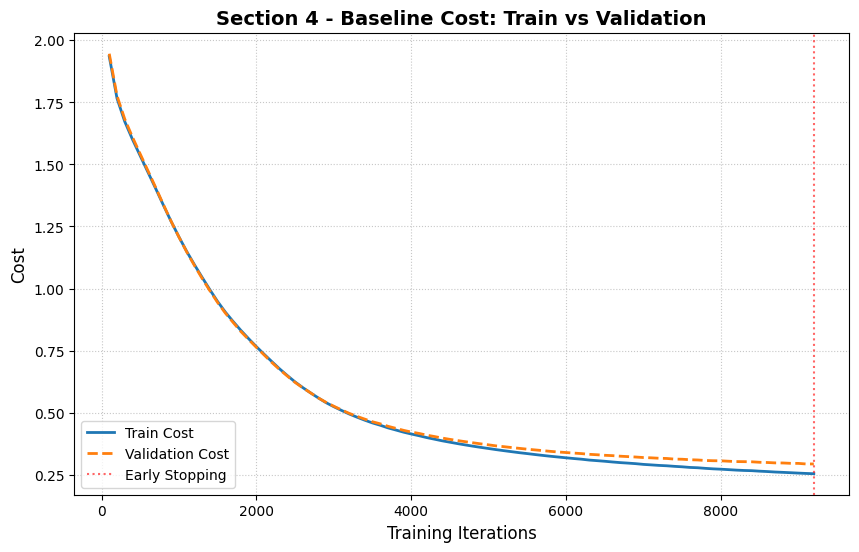


Train Accuracy: 93.02%
Validation Accuracy: 92.16%
Test Accuracy: 92.43%


In [75]:
# --- 1. Baseline ---
GLOBAL_USE_BATCHNORM = False
GLOBAL_LAMBD = 0
GLOBAL_PARAMETERS = {} 

print("\n" + "="*50)
print("--- Starting Training: BASELINE ---")
print("="*50)

parameters_base, t_costs_b, v_costs_b, iters_b = l_layer_model(train_x, train_y, layers_dims, learning_rate, num_iterations, batch_size)
plot_costs(iters_b, t_costs_b, v_costs_b, "Section 4 - Baseline Cost: Train vs Validation")

print(f"\nTrain Accuracy: {predict(train_x, train_y, parameters_base) * 100:.2f}%")
print(f"Validation Accuracy: {predict(val_x, val_y, parameters_base) * 100:.2f}%")
print(f"Test Accuracy: {predict(test_x, test_y_oh, parameters_base) * 100:.2f}%")


--- Starting Training: BATCHNORM ---
Iteration 100 | Train Cost: 1.628100 | Val Cost: 1.634674
Iteration 200 | Train Cost: 1.515106 | Val Cost: 1.524372
Iteration 300 | Train Cost: 1.425251 | Val Cost: 1.437194
Iteration 400 | Train Cost: 1.346896 | Val Cost: 1.358601
Iteration 500 | Train Cost: 1.278118 | Val Cost: 1.289602
Iteration 600 | Train Cost: 1.241405 | Val Cost: 1.251844
Iteration 700 | Train Cost: 1.176496 | Val Cost: 1.188455
Iteration 800 | Train Cost: 1.124622 | Val Cost: 1.138288
Iteration 900 | Train Cost: 1.076577 | Val Cost: 1.090761
Iteration 1000 | Train Cost: 1.034320 | Val Cost: 1.048578
Iteration 1100 | Train Cost: 0.997322 | Val Cost: 1.011350
Iteration 1200 | Train Cost: 0.963535 | Val Cost: 0.977925
Iteration 1300 | Train Cost: 0.932679 | Val Cost: 0.945926
Iteration 1400 | Train Cost: 0.904052 | Val Cost: 0.916570
Iteration 1500 | Train Cost: 0.875738 | Val Cost: 0.888506
Iteration 1600 | Train Cost: 0.848979 | Val Cost: 0.861674
Iteration 1700 | Train Cost

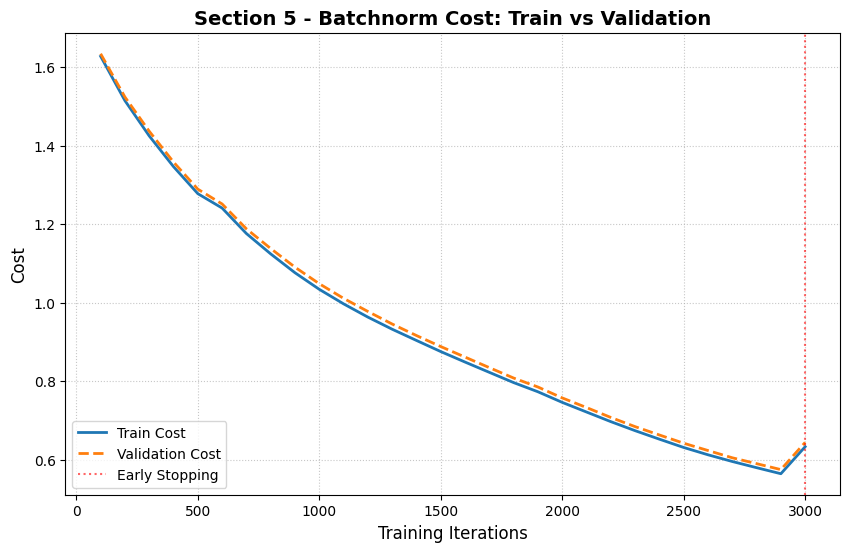


Train Accuracy: 85.21%
Validation Accuracy: 85.08%
Test Accuracy: 85.26%


In [76]:
# --- 2. Batchnorm ---
GLOBAL_USE_BATCHNORM = True
GLOBAL_LAMBD = 0
GLOBAL_PARAMETERS = {} 

print("\n" + "="*50)
print("--- Starting Training: BATCHNORM ---")
print("="*50)

parameters_bn, t_costs_bn, v_costs_bn, iters_bn = l_layer_model(train_x, train_y, layers_dims, learning_rate, num_iterations, batch_size)
plot_costs(iters_bn, t_costs_bn, v_costs_bn, "Section 5 - Batchnorm Cost: Train vs Validation")

print(f"\nTrain Accuracy: {predict(train_x, train_y, parameters_bn) * 100:.2f}%")
print(f"Validation Accuracy: {predict(val_x, val_y, parameters_bn) * 100:.2f}%")
print(f"Test Accuracy: {predict(test_x, test_y_oh, parameters_bn) * 100:.2f}%")



--- Starting Training: L2 REGULARIZATION ---
Iteration 100 | Train Cost: 1.935745 | Val Cost: 1.948323
Iteration 200 | Train Cost: 1.767463 | Val Cost: 1.779214
Iteration 300 | Train Cost: 1.674351 | Val Cost: 1.685777
Iteration 400 | Train Cost: 1.602652 | Val Cost: 1.613243
Iteration 500 | Train Cost: 1.536696 | Val Cost: 1.545612
Iteration 600 | Train Cost: 1.471035 | Val Cost: 1.478331
Iteration 700 | Train Cost: 1.405272 | Val Cost: 1.410934
Iteration 800 | Train Cost: 1.338282 | Val Cost: 1.341852
Iteration 900 | Train Cost: 1.272984 | Val Cost: 1.274843
Iteration 1000 | Train Cost: 1.211407 | Val Cost: 1.212124
Iteration 1100 | Train Cost: 1.152803 | Val Cost: 1.152273
Iteration 1200 | Train Cost: 1.098964 | Val Cost: 1.097340
Iteration 1300 | Train Cost: 1.047536 | Val Cost: 1.044599
Iteration 1400 | Train Cost: 0.997721 | Val Cost: 0.995043
Iteration 1500 | Train Cost: 0.950126 | Val Cost: 0.947611
Iteration 1600 | Train Cost: 0.907659 | Val Cost: 0.905160
Iteration 1700 | Tr

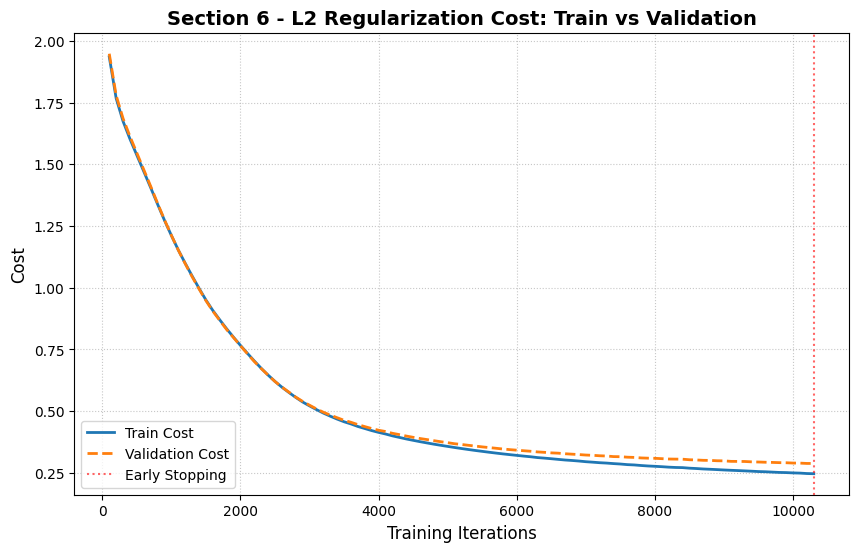


Train Accuracy: 93.32%
Validation Accuracy: 92.27%
Test Accuracy: 92.76%

--- Weights Comparison ---
Layer | Avg Weight (No L2) | Avg Weight (With L2)
---------------------------------------------
  1   |      0.045463      |      0.042711
  2   |      0.357442      |      0.346714
  3   |      0.724425      |      0.699542


In [77]:
# --- 3. L2 Regularization ---
GLOBAL_USE_BATCHNORM = False
GLOBAL_LAMBD = 0.5
GLOBAL_PARAMETERS = {} 

print("\n" + "="*50)
print("--- Starting Training: L2 REGULARIZATION ---")
print("="*50)

parameters_l2, t_costs_l2, v_costs_l2, iters_l2 = l_layer_model(train_x, train_y, layers_dims, learning_rate, num_iterations, batch_size)
plot_costs(iters_l2, t_costs_l2, v_costs_l2, "Section 6 - L2 Regularization Cost: Train vs Validation")

print(f"\nTrain Accuracy: {predict(train_x, train_y, parameters_l2) * 100:.2f}%")
print(f"Validation Accuracy: {predict(val_x, val_y, parameters_l2) * 100:.2f}%")
print(f"Test Accuracy: {predict(test_x, test_y_oh, parameters_l2) * 100:.2f}%")

print("\n" + "="*50)
print("--- Weights Comparison ---")
print("="*50)
compare_weights(parameters_base,parameters_l2)


## Beyond the Scope: Further Insights

In [78]:
# compare lambda
lambda_values = [0, 0.01, 0.1, 0.5,1,5] 
results = {}

for l in lambda_values:
    print(f"--- Training with lambda = {l} ---")
    GLOBAL_LAMBD = l
    params, _ ,_,_= l_layer_model(
        train_x, train_y, 
        layers_dims    = [784, 20, 7, 10], 
        learning_rate  = 0.009, 
        num_iterations = 3000, 
        batch_size     = 512 
    )
    results[l] = params

--- Training with lambda = 0 ---
Iteration 100 | Train Cost: 1.906339 | Val Cost: 1.916044
Iteration 200 | Train Cost: 1.683940 | Val Cost: 1.694630
Iteration 300 | Train Cost: 1.528218 | Val Cost: 1.540712
Iteration 400 | Train Cost: 1.407072 | Val Cost: 1.420443
Iteration 500 | Train Cost: 1.309774 | Val Cost: 1.322389
Iteration 600 | Train Cost: 1.225021 | Val Cost: 1.236409
Iteration 700 | Train Cost: 1.144744 | Val Cost: 1.154469
Iteration 800 | Train Cost: 1.071328 | Val Cost: 1.080446
Iteration 900 | Train Cost: 1.005749 | Val Cost: 1.013678
Iteration 1000 | Train Cost: 0.947372 | Val Cost: 0.955043
Iteration 1100 | Train Cost: 0.892724 | Val Cost: 0.900049
Iteration 1200 | Train Cost: 0.841999 | Val Cost: 0.849696
Iteration 1300 | Train Cost: 0.792403 | Val Cost: 0.800027
Iteration 1400 | Train Cost: 0.745211 | Val Cost: 0.752897
Iteration 1500 | Train Cost: 0.701429 | Val Cost: 0.709077
Iteration 1600 | Train Cost: 0.664494 | Val Cost: 0.671709
Iteration 1700 | Train Cost: 0.6

In [79]:
compare_all_weights(results)

Layer      | Baseline (L=0)   | L=0.01         | L=0.1          | L=0.5          | L=1            | L=5           
------------------------------------------------------------------------------------------------------------------
W1        | 0.047483         | 0.047418       | 0.046837       | 0.044382       | 0.041589       | 0.023144      
W2        | 0.376732         | 0.376356       | 0.373200       | 0.359771       | 0.344523       | 0.264363      
W3        | 0.620443         | 0.619719       | 0.613143       | 0.585452       | 0.554132       | 0.384926      


In [80]:
compare_all_accuracies(results, train_x, train_y, val_x, val_y, test_x, test_y_oh)

Lambda     | Train Acc    | Val Acc      | Test Acc    
-------------------------------------------------------
0          | 92.80      % | 92.13      % | 92.47      %
0.01       | 92.79      % | 92.14      % | 92.46      %
0.1        | 92.80      % | 92.17      % | 92.47      %
0.5        | 92.71      % | 92.06      % | 92.39      %
1          | 92.54      % | 91.88      % | 92.18      %
5          | 92.33      % | 92.07      % | 92.06      %


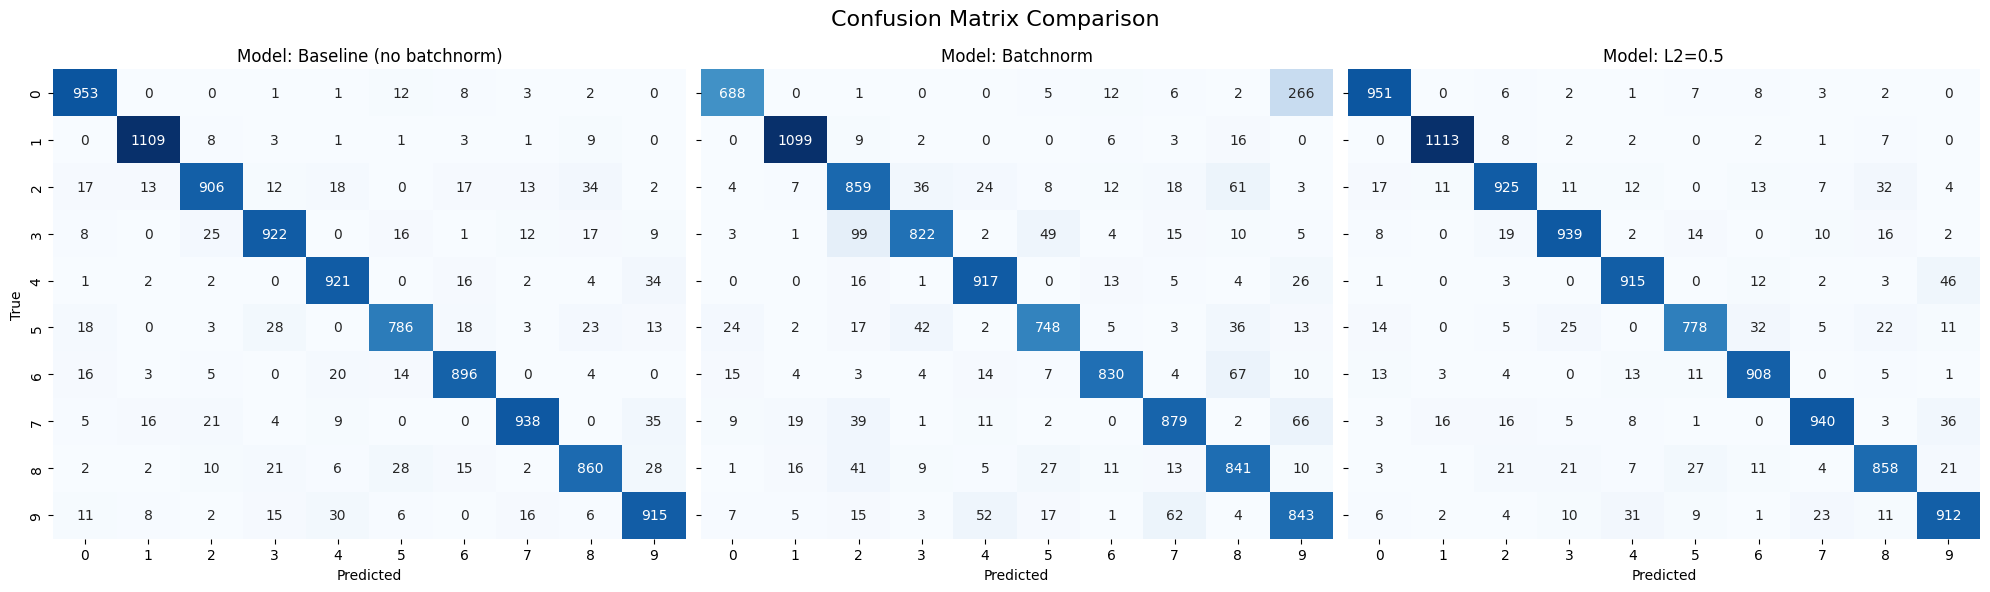

In [81]:
models_to_compare = [('Baseline (no batchnorm)', params),('Batchnorm', parameters_bn), ('L2=0.5', results[0.5])]
plot_three_cms(models_to_compare, test_x, test_y_oh)